# Real-Time Speech Emotion Recognition — Optimized for RTX 3050 Ti (4GB)
### ALL 3 Datasets: RAVDESS + CREMA-D + IEMOCAP (via CSV)

| Component | Spec |
|-----------|------|
| GPU | RTX 3050 Ti Laptop, 4 GB VRAM |
| RAM | 16 GB DDR4 |
| CPU | i5-12450H, 12 threads |

```
project/
├── training_data.csv          ← IEMOCAP labels CSV
├── data/
│   ├── ravdess/Actor_01/...
│   ├── crema-d/AudioWAV/...
│   └── iemocap/Session1/sentences/wav/...
```

In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip(
    'torch', 'torchaudio',
    'transformers', 'accelerate',
    'openai-whisper', 'openai',
    'scikit-learn', 'seaborn',
    'tqdm', 'pandas', 'matplotlib',
    'onnx', 'onnxruntime'
)

try:
    pip('sounddevice')
except Exception:
    print('sounddevice install failed — real-time mic cell will be skipped')

print('All packages installed.')

All packages installed.


In [2]:
import os, re, random, json, time, warnings, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

CFG = {
    'seed'        : 42,
    'sr'          : 16_000,
    'clip_sec'    : 2.0,
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'n_fft'       : 512,
    'hop_length'  : 160,
    'win_length'  : 400,
    'f_min'       : 80,
    'f_max'       : 7600,
    'batch_size'  : 32,   # was 16 — 32 safe on 4GB for CNN/LSTM
    'epochs'      : 80,   # was 30 — needs 60-80 to converge
    'lr'          : 1e-4, # confirmed: 3e-4 caused overfitting (CNN gap=0.24)
    'dropout'     : 0.45, # was 0.3 — stronger regularisation confirmed needed
    'num_workers' : 0,
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_classes' : 6,
}

HUBERT_CFG = {
    **CFG,
    'lr'         : 2e-5,  # was 1e-5
    'batch_size' : 2,
    'epochs'     : 50,   # was 30 — HuBERT needs 50 epochs
    'num_workers': 0,
}

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if CFG['device'] == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])
    torch.backends.cudnn.benchmark = True

print(f"Device    : {CFG['device']}")
if CFG['device'] == 'cuda':
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"PyTorch   : {torch.__version__}")
print(f"torchaudio: {torchaudio.__version__}")

Device    : cuda
GPU       : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM      : 4.3 GB
PyTorch   : 2.6.0+cu124
torchaudio: 2.6.0+cu124


c:\Users\yasha\Desktop\RP_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parsing RAVDESS...
  1248 samples | 24 speakers
Parsing CREMA-D...
  7442 samples | 91 speakers
Parsing IEMOCAP from CSV...
IEMOCAP CSV : 9949 samples loaded | 0 paths not found
Speakers    : 2
label
angry      4231
happy      2735
neutral    1741
sad        1097
fearful     104
disgust      41

Total samples : 18639
Total speakers: 117
dataset
iemocap    9949
cremad     7442
ravdess    1248
label
angry      5694
happy      4198
neutral    3116
sad        2560
fearful    1567
disgust    1504


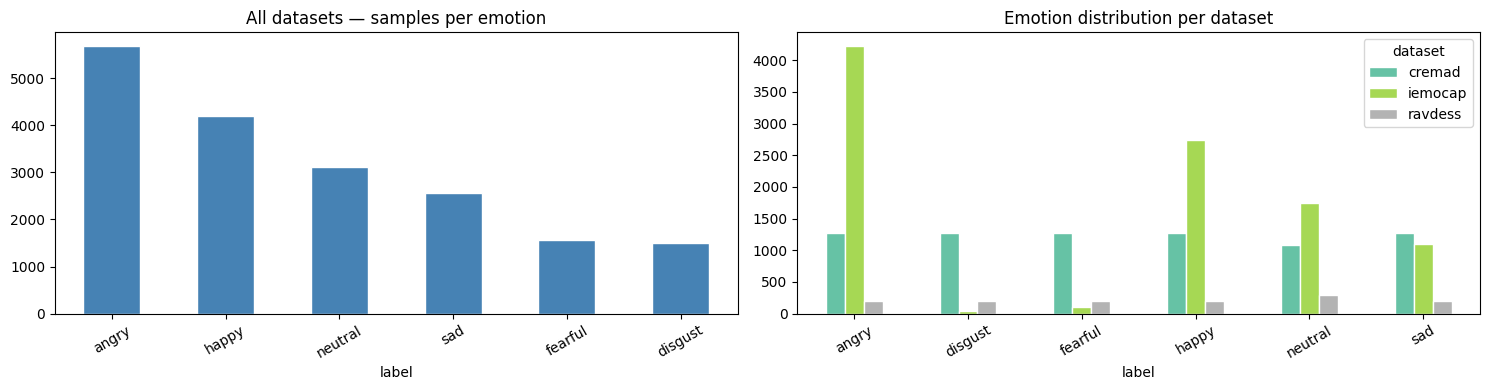

In [3]:
UNIFIED_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']

# ---------- RAVDESS ----------
RAVDESS_MAP = {
    '01': 'neutral', '02': 'neutral', '03': 'happy',
    '04': 'sad',     '05': 'angry',   '06': 'fearful',
    '07': 'disgust', '08': None,
}

def parse_ravdess(root='data/ravdess'):
    records = []
    for wav in Path(root).rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) != 7:
            continue
        label    = RAVDESS_MAP.get(parts[2])
        actor_id = int(parts[6])
        if label:
            records.append({'path': str(wav), 'label': label,
                            'speaker_id': f'R{actor_id:03d}', 'dataset': 'ravdess'})
    return pd.DataFrame(records)


# ---------- CREMA-D ----------
CREMAD_MAP = {
    'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fearful',
    'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad',
}

def parse_cremad(audio_dir='data/crema-d/AudioWAV'):
    records = []
    for wav in Path(audio_dir).glob('*.wav'):
        parts = wav.stem.split('_')
        if len(parts) < 3:
            continue
        label = CREMAD_MAP.get(parts[2])
        if label:
            records.append({'path': str(wav), 'label': label,
                            'speaker_id': f'C{parts[0]}', 'dataset': 'cremad'})
    return pd.DataFrame(records)


# ---------- IEMOCAP — from CSV ----------
IEMOCAP_CSV_MAP = {
    'Frustration': 'angry',
    'Anger'      : 'angry',
    'Excited'    : 'happy',
    'Neutral'    : 'neutral',
    'Sadness'    : 'sad',
    'Happiness'  : 'happy',
    'Fear'       : 'fearful',
    'Disgust'    : 'disgust',
    'Surprise'   : None,
}

def parse_iemocap_csv(csv_path='training_data.csv', local_root='data/iemocap'):
    if not Path(csv_path).exists():
        print(f'WARNING: {csv_path} not found — skipping IEMOCAP')
        return pd.DataFrame(columns=['path','label','speaker_id','dataset'])

    df_csv  = pd.read_csv(csv_path)
    records = []
    missing = 0

    for _, row in df_csv.iterrows():
        label = IEMOCAP_CSV_MAP.get(row['emotion'])
        if not label:
            continue

        # Remap kaggle path → local path
        # /kaggle/working/audio_files/Session5/sentences/... → data/iemocap/Session5/sentences/...
        old_path = row['audio_path']
        rel_path = old_path.split('audio_files/')[-1]   # Session5/sentences/wav/...
        new_path = str(Path(local_root) / rel_path)

        if not Path(new_path).exists():
            missing += 1
            continue

        # Speaker ID from file_id: Ses05M_script03_2_M016 → I5M
        fid        = row['file_id']
        session_num= fid[3]                              # '5'
        suffix     = fid.split('_')[-1]                  # 'M016'
        gender     = 'M' if suffix.startswith('M') else 'F'
        speaker_id = f'I{session_num}{gender}'

        records.append({'path': new_path, 'label': label,
                        'speaker_id': speaker_id, 'dataset': 'iemocap'})

    df = pd.DataFrame(records)
    print(f'IEMOCAP CSV : {len(df)} samples loaded | {missing} paths not found')
    if len(df):
        print(f'Speakers    : {df["speaker_id"].nunique()}')
        print(df['label'].value_counts().to_string())
    return df


# ---- Parse all 3 ----
print('Parsing RAVDESS...')
df_rav = parse_ravdess('data/ravdess')
print(f'  {len(df_rav)} samples | {df_rav["speaker_id"].nunique()} speakers')

print('Parsing CREMA-D...')
df_cre = parse_cremad('data/crema-d/AudioWAV')
print(f'  {len(df_cre)} samples | {df_cre["speaker_id"].nunique()} speakers')

print('Parsing IEMOCAP from CSV...')
df_iem = parse_iemocap_csv(
    csv_path='training_data.csv',
    local_root='data/iemocap'
)

# ---- Combine ----
df_all = pd.concat([df_rav, df_cre, df_iem], ignore_index=True)
le     = LabelEncoder().fit(UNIFIED_EMOTIONS)
df_all['label_id'] = le.transform(df_all['label'])

print(f'\nTotal samples : {len(df_all)}')
print(f'Total speakers: {df_all["speaker_id"].nunique()}')
print(df_all['dataset'].value_counts().to_string())
print(df_all['label'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
df_all['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('All datasets — samples per emotion')
axes[0].tick_params(axis='x', rotation=30)
pivot = df_all.groupby(['label','dataset']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Emotion distribution per dataset')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [4]:
# ============================================================
# DIAGNOSTIC — Run this BEFORE training
# Check: 1) delete stale cache  2) IEMOCAP sample count
# ============================================================
import os
from pathlib import Path

# Step 1: Delete stale feature cache (MUST do if you ran any previous version)
cache_file = 'features_cache.pkl'
if Path(cache_file).exists():
    os.remove(cache_file)
    print(f"Deleted stale cache: {cache_file}")
else:
    print("No cache file found (clean start)")

# Step 2: Verify dataset loading counts
print("\n=== Dataset sample counts ===")
for name, df in [("RAVDESS", df_rav), ("CREMA-D", df_cre), ("IEMOCAP", df_iem)]:
    if len(df) == 0:
        print(f"  {name}: 0 samples ← PROBLEM: check path")
    else:
        print(f"  {name}: {len(df):,} samples | {df['speaker_id'].nunique()} speakers")
        print(f"    emotions: {df['label'].value_counts().to_dict()}")

print(f"\n  TOTAL : {len(df_all):,} samples")

# Step 3: Verify a few IEMOCAP paths actually exist
print("\n=== IEMOCAP path check (first 5) ===")
if len(df_iem) > 0:
    for _, row in df_iem.head(5).iterrows():
        exists = Path(row["path"]).exists()
        status = "OK" if exists else "MISSING"
        print(f"  [{status}] {row['path'][:80]}")
else:
    print("  No IEMOCAP samples loaded — check csv_path and local_root in parse_iemocap_csv()")
    print("  Expected: csv_path='training_data.csv' in the same folder as this notebook")
    print("  Expected: local_root='data/iemocap'")

# Step 4: Confirm updated config values
print(f"\n=== Config check ===")
print(f"  batch_size : {CFG['batch_size']}  (should be 32)")
print(f"  epochs     : {CFG['epochs']}  (should be 80)")
print(f"  lr         : {CFG['lr']}  (should be 3e-4)")
print(f"  num_workers: {CFG['num_workers']}  (should be 0 on Windows)")
print(f"  device     : {CFG['device']}")
if CFG['device'] == 'cuda':
    free = torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()
    print(f"  VRAM free  : {free/1e9:.2f} GB")


Deleted stale cache: features_cache.pkl

=== Dataset sample counts ===
  RAVDESS: 1,248 samples | 24 speakers
    emotions: {'neutral': 288, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192}
  CREMA-D: 7,442 samples | 91 speakers
    emotions: {'angry': 1271, 'disgust': 1271, 'fearful': 1271, 'happy': 1271, 'sad': 1271, 'neutral': 1087}
  IEMOCAP: 9,949 samples | 2 speakers
    emotions: {'angry': 4231, 'happy': 2735, 'neutral': 1741, 'sad': 1097, 'fearful': 104, 'disgust': 41}

  TOTAL : 18,639 samples

=== IEMOCAP path check (first 5) ===
  [OK] data\iemocap\Session5\sentences\wav\Ses05M_script03_2\Ses05M_script03_2_M016.wav
  [OK] data\iemocap\Session5\sentences\wav\Ses05M_script03_2\Ses05M_script03_2_F039.wav
  [OK] data\iemocap\Session5\sentences\wav\Ses05M_script03_2\Ses05M_script03_2_M024.wav
  [OK] data\iemocap\Session5\sentences\wav\Ses05M_script03_2\Ses05M_script03_2_M009.wav
  [OK] data\iemocap\Session5\sentences\wav\Ses05M_script03_2\Ses05M_script03_2_

In [5]:
def speaker_independent_split(df, val_ratio=0.15, test_ratio=0.15, seed=42):
    speakers = df['speaker_id'].unique().tolist()
    random.seed(seed)
    random.shuffle(speakers)
    n         = len(speakers)
    n_test    = int(n * test_ratio)
    n_val     = int(n * val_ratio)
    test_spk  = set(speakers[:n_test])
    val_spk   = set(speakers[n_test : n_test + n_val])
    train_spk = set(speakers[n_test + n_val:])
    df_train  = df[df['speaker_id'].isin(train_spk)].reset_index(drop=True)
    df_val    = df[df['speaker_id'].isin(val_spk)].reset_index(drop=True)
    df_test   = df[df['speaker_id'].isin(test_spk)].reset_index(drop=True)
    return df_train, df_val, df_test

df_train, df_val, df_test = speaker_independent_split(df_all)

print(f'Train: {len(df_train):,} samples | {df_train["speaker_id"].nunique()} speakers')
print(f'Val  : {len(df_val):,} samples | {df_val["speaker_id"].nunique()} speakers')
print(f'Test : {len(df_test):,} samples | {df_test["speaker_id"].nunique()} speakers')

assert not (set(df_train['speaker_id']) & set(df_test['speaker_id'])), 'TRAIN/TEST LEAKAGE!'
assert not (set(df_train['speaker_id']) & set(df_val['speaker_id'])),  'TRAIN/VAL LEAKAGE!'
assert not (set(df_val['speaker_id'])   & set(df_test['speaker_id'])), 'VAL/TEST LEAKAGE!'
print('No speaker leakage confirmed.')

for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'{split_name}: {split_df["dataset"].value_counts().to_dict()}')

Train: 11,364 samples | 83 speakers
Val  : 5,941 samples | 17 speakers
Test : 1,334 samples | 17 speakers
No speaker leakage confirmed.
Train: {'cremad': 5234, 'iemocap': 5194, 'ravdess': 936}
Val: {'iemocap': 4755, 'cremad': 978, 'ravdess': 208}
Test: {'cremad': 1230, 'ravdess': 104}


RAVDESS   : mfcc=torch.Size([1, 120, 201]) | lmel=torch.Size([1, 128, 201]) | wav=torch.Size([1, 32000])
CREMA-D   : mfcc=torch.Size([1, 120, 201]) | lmel=torch.Size([1, 128, 201]) | wav=torch.Size([1, 32000])
IEMOCAP   : mfcc=torch.Size([1, 120, 201]) | lmel=torch.Size([1, 128, 201]) | wav=torch.Size([1, 32000])


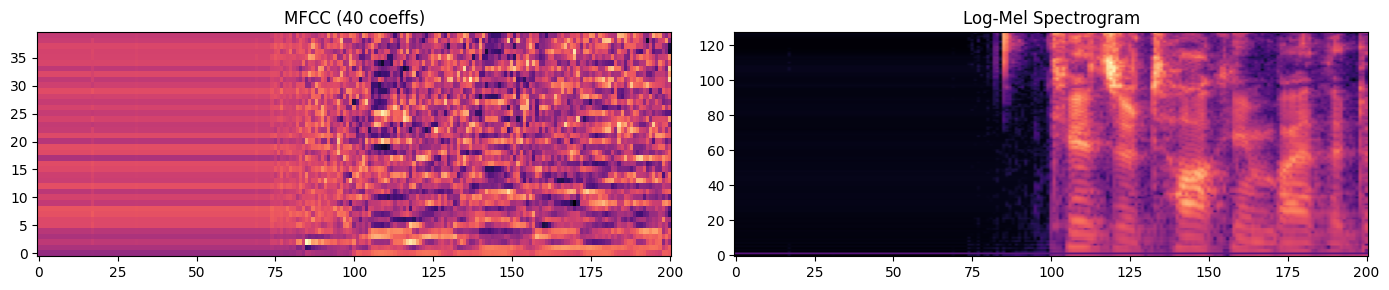

In [6]:
class AudioPreprocessor:
    def __init__(self, cfg=CFG):
        self.sr        = cfg['sr']
        self.n_samples = int(cfg['sr'] * cfg['clip_sec'])
        self.mfcc_tfm  = T.MFCC(
            sample_rate=cfg['sr'], n_mfcc=cfg['n_mfcc'],
            melkwargs={'n_fft': cfg['n_fft'], 'hop_length': cfg['hop_length'],
                       'win_length': cfg['win_length'], 'n_mels': cfg['n_mels'],
                       'f_min': cfg['f_min'], 'f_max': cfg['f_max']}
        )
        self.mel_tfm   = T.MelSpectrogram(
            sample_rate=cfg['sr'], n_fft=cfg['n_fft'], hop_length=cfg['hop_length'],
            win_length=cfg['win_length'], n_mels=cfg['n_mels'],
            f_min=cfg['f_min'], f_max=cfg['f_max']
        )
        self.amp_to_db = T.AmplitudeToDB(top_db=80)
        self.delta     = T.ComputeDeltas()

    def load(self, path):
        wav, sr = torchaudio.load(str(path))
        if wav.shape[0] > 1:
            wav = wav.mean(0, keepdim=True)
        if sr != self.sr:
            wav = T.Resample(sr, self.sr)(wav)
        return wav

    def pad_or_trim(self, wav):
        n = wav.shape[-1]
        if n >= self.n_samples:
            return wav[..., :self.n_samples]
        pad = self.n_samples - n
        return F.pad(wav, (pad // 2, pad - pad // 2))

    @staticmethod
    def normalize(t):
        mean = t.mean(dim=-1, keepdim=True)
        std  = t.std(dim=-1, keepdim=True).clamp(min=1e-6)
        return (t - mean) / std

    def __call__(self, path):
        wav      = self.load(path)
        wav      = self.pad_or_trim(wav)
        mfcc     = self.mfcc_tfm(wav)
        d1       = self.delta(mfcc)
        d2       = self.delta(d1)
        mfcc_f   = torch.cat([mfcc, d1, d2], dim=1)
        mel      = self.mel_tfm(wav)
        lmel     = self.amp_to_db(mel)
        wav_norm = wav / wav.abs().max().clamp(min=1e-6)
        return self.normalize(mfcc_f), self.normalize(lmel), wav_norm


preprocessor = AudioPreprocessor(CFG)

for ds_name, ds_df in [('RAVDESS', df_rav), ('CREMA-D', df_cre), ('IEMOCAP', df_iem)]:
    if len(ds_df) == 0:
        print(f'{ds_name}: EMPTY — check path')
        continue
    mfcc, lmel, wav = preprocessor(ds_df['path'].iloc[0])
    print(f'{ds_name:10s}: mfcc={mfcc.shape} | lmel={lmel.shape} | wav={wav.shape}')

mfcc, lmel, wav = preprocessor(df_train['path'].iloc[0])
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(mfcc[0, :40].numpy(), aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('MFCC (40 coeffs)')
axes[1].imshow(lmel[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

In [7]:
CACHE_FILE = 'features_cache.pkl'

def precompute_features(df, preprocessor, cache_file=CACHE_FILE):
    if Path(cache_file).exists():
        print(f'Loading cached features from {cache_file}...')
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    print(f'Pre-computing features for {len(df)} samples — runs ONCE then saved...')
    cache = {}
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Caching'):
        try:
            mfcc, lmel, wav = preprocessor(row['path'])
            cache[row['path']] = (mfcc, lmel, wav)
        except Exception as e:
            print(f'  Skipping {row["path"]}: {e}')
    with open(cache_file, 'wb') as f:
        pickle.dump(cache, f)
    print(f'Saved to {cache_file}')
    return cache

feature_cache = precompute_features(df_all, preprocessor)
print(f'Cache: {len(feature_cache)} samples')

Pre-computing features for 18639 samples — runs ONCE then saved...


Caching: 100%|██████████| 18639/18639 [03:45<00:00, 82.81it/s]


Saved to features_cache.pkl
Cache: 18639 samples


In [8]:
class SpeechAugment:
    def __init__(self, sr=16_000, p=0.5):
        self.sr = sr
        self.p  = p

    def add_gaussian_noise(self, wav, snr_db_range=(10, 30)):
        snr       = random.uniform(*snr_db_range)
        sig_pow   = wav.norm(p=2) ** 2 / wav.numel()
        noise_pow = sig_pow / (10 ** (snr / 10))
        return (wav + torch.randn_like(wav) * noise_pow.sqrt()).clamp(-1.0, 1.0)

    def add_pink_noise(self, wav, noise_level=(0.002, 0.015)):
        f     = torch.fft.rfftfreq(wav.shape[-1]).clamp(min=1e-6)
        pink  = (1.0 / f.sqrt()) * torch.randn(len(f), dtype=torch.complex64)
        noise = torch.fft.irfft(pink, n=wav.shape[-1]).unsqueeze(0)
        noise = noise / noise.abs().max().clamp(min=1e-6)
        alpha = random.uniform(*noise_level)
        return (wav + alpha * noise).clamp(-1.0, 1.0)

    def volume_perturb(self, wav, db_range=(-6, 6)):
        db = random.uniform(*db_range)
        return (wav * (10 ** (db / 20))).clamp(-1.0, 1.0)

    def time_mask(self, spec, max_pct=0.20):
        T = spec.shape[-1]
        w = max(1, int(T * max_pct * random.random()))
        s = random.randint(0, max(0, T - w - 1))
        spec = spec.clone(); spec[..., s:s + w] = 0.0
        return spec

    def freq_mask(self, spec, max_pct=0.15):
        Fd = spec.shape[-2]
        w  = max(1, int(Fd * max_pct * random.random()))
        s  = random.randint(0, max(0, Fd - w - 1))
        spec = spec.clone(); spec[:, s:s + w, :] = 0.0
        return spec

    def time_stretch_spec(self, spec, rate_range=(0.85, 1.15)):
        rate  = random.uniform(*rate_range)
        T     = spec.shape[-1]
        new_T = max(1, int(T / rate))
        out   = F.interpolate(
            spec.unsqueeze(0).float(),
            size=(spec.shape[-2], new_T),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        return out[..., :T] if new_T >= T else F.pad(out, (0, T - new_T))

    def __call__(self, wav, spec):
        if random.random() < self.p:
            fn  = random.choice([self.add_gaussian_noise,
                                  self.add_pink_noise,
                                  self.volume_perturb])
            wav = fn(wav)
        if random.random() < self.p:
            spec = self.time_mask(spec)
        if random.random() < self.p:
            spec = self.freq_mask(spec)
        if random.random() < self.p:
            spec = self.time_stretch_spec(spec)
        return wav, spec

augmenter = SpeechAugment(sr=CFG['sr'], p=0.5)
print('Augmenter ready.')

Augmenter ready.


In [9]:
class EmotionDataset(Dataset):
    def __init__(self, df, preprocessor, augmenter=None, augment=False, cache=None):
        self.df           = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.augmenter    = augmenter
        self.augment      = augment
        self.cache        = cache

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.cache and row['path'] in self.cache:
            mfcc, lmel, wav = self.cache[row['path']]
        else:
            mfcc, lmel, wav = self.preprocessor(row['path'])

        if self.augment and self.augmenter:
            wav, lmel = self.augmenter(wav, lmel)
            m    = self.preprocessor.mfcc_tfm(wav)
            d1   = self.preprocessor.delta(m)
            d2   = self.preprocessor.delta(d1)
            mfcc = self.preprocessor.normalize(torch.cat([m, d1, d2], dim=1))
            lmel = self.preprocessor.normalize(lmel)

        return {
            'mfcc' : mfcc,
            'spec' : lmel,
            'wav'  : wav.squeeze(0),
            'label': torch.tensor(row['label_id'], dtype=torch.long),
        }


def make_weighted_sampler(df):
    counts  = Counter(df['label_id'].tolist())
    total   = len(df)
    w_class = {c: total / cnt for c, cnt in counts.items()}
    weights = [w_class[l] for l in df['label_id']]
    return WeightedRandomSampler(weights, len(weights), replacement=True)


train_ds = EmotionDataset(df_train, preprocessor, augmenter, augment=True,  cache=feature_cache)
val_ds   = EmotionDataset(df_val,   preprocessor, augment=False, cache=feature_cache)
test_ds  = EmotionDataset(df_test,  preprocessor, augment=False, cache=feature_cache)

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'],
    sampler=make_weighted_sampler(df_train),
    num_workers=0, pin_memory=(CFG['device'] == 'cuda')
)
val_loader  = DataLoader(val_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')
sample = next(iter(train_loader))
print(f"spec={sample['spec'].shape} | mfcc={sample['mfcc'].shape} | wav={sample['wav'].shape}")

Train batches : 356
Val   batches : 186
Test  batches : 42
spec=torch.Size([32, 1, 128, 201]) | mfcc=torch.Size([32, 1, 120, 201]) | wav=torch.Size([32, 32000])


In [ ]:
# NOTE: AdaptiveAvgPool2d replaced with AvgPool2d — fixes ONNX export error
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'], dropout=CFG['dropout']):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.AvgPool2d((4, 4)),   # output: [B, 128, 4, 6]
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*6, 256), nn.ReLU(), nn.Dropout(dropout),  # 3072
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


class CNNLSTM(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'],
                 lstm_hidden=256, lstm_layers=2, dropout=CFG['dropout']):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,1)),
        )
        self.rnn = nn.LSTM(
            input_size=128 * 16, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        self.attn_fc    = nn.Linear(lstm_hidden * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat   = self.cnn(x)
        B, C, F_dim, T = feat.shape
        feat   = feat.permute(0, 3, 1, 2).reshape(B, T, C * F_dim)
        out, _ = self.rnn(feat)
        attn   = torch.softmax(self.attn_fc(out), dim=1)
        ctx    = (attn * out).sum(dim=1)
        return self.classifier(ctx)


class HuBERTEmotionClassifier(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'], freeze_bottom=8, dropout=0.1):
        super().__init__()
        from transformers import HubertModel
        self.hubert = HubertModel.from_pretrained('facebook/hubert-base-ls960', use_safetensors=True)
        self.hubert.gradient_checkpointing_enable()
        for p in self.hubert.feature_extractor.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i < freeze_bottom:
                for p in layer.parameters():
                    p.requires_grad = False
        h               = self.hubert.config.hidden_size
        n_tuned         = len(self.hubert.encoder.layers) - freeze_bottom
        self.layer_weights = nn.Parameter(torch.ones(n_tuned) / n_tuned)
        self.n_tuned    = n_tuned
        self.proj       = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, wav, attention_mask=None):
        out     = self.hubert(wav, attention_mask=attention_mask, output_hidden_states=True)
        layers  = torch.stack(out.hidden_states[-self.n_tuned:], dim=1)
        weights = torch.softmax(self.layer_weights, dim=0)
        pooled  = (layers * weights[None,:,None,None]).sum(1).mean(1)
        return self.proj(pooled)


# Verify BaselineCNN output shape with fixed pooling
with torch.no_grad():
    test_cnn = BaselineCNN()
    out = test_cnn(torch.randn(2, 1, 128, 200))
    print(f'BaselineCNN output: {out.shape}')  # should be [2, 6]

for name, model in [('BaselineCNN', BaselineCNN()), ('CNN+LSTM', CNNLSTM())]:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name:20s}: {trainable/1e6:.2f}M trainable / {total/1e6:.2f}M total')

BaselineCNN output: torch.Size([2, 6])
BaselineCNN         : 1.08M trainable / 1.08M total
CNN+LSTM            : 6.59M trainable / 6.59M total


In [11]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, num_classes=CFG['num_classes']):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.ones(num_classes) / num_classes if alpha is None \
                     else torch.tensor(alpha, dtype=torch.float32)

    def forward(self, logits, targets):
        # Label smoothing: reduces overconfidence on noisy IEMOCAP labels
        n_cls = logits.size(1)
        smooth = 0.1
        with torch.no_grad():
            smooth_targets = torch.full_like(logits, smooth / (n_cls - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - smooth)
        probs     = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        pt    = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        lpt   = (smooth_targets * log_probs).sum(dim=-1)
        alpha = self.alpha.to(logits.device).gather(0, targets)
        return (-alpha * (1 - pt) ** self.gamma * lpt).mean()


def run_epoch(model, loader, criterion, optimizer, scheduler,
              device, train=True, use_wav=False, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='Train' if train else 'Eval ', leave=False):
            labels = batch['label'].to(device)
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(inp)
                loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler:
                    scheduler.step()
            total_loss  += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(labels_all, preds_all)
    f1   = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


def train_model(model_class, model_kwargs, cfg=CFG,
                use_wav=False, model_name='model',
                t_loader=None, v_loader=None):
    t_loader  = t_loader or train_loader
    v_loader  = v_loader or val_loader
    device    = torch.device(cfg['device'])
    model     = model_class(**model_kwargs).to(device)
    criterion = FocalLoss(gamma=2.0, num_classes=cfg['num_classes'])
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=5e-4  # was 1e-4 — stronger L2 regularisation
    )
    scheduler = OneCycleLR(
        optimizer, max_lr=cfg['lr'],
        steps_per_epoch=len(t_loader),
        epochs=cfg['epochs'], pct_start=0.1
    )
    scaler  = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
    best_f1, patience, wait = 0.0, 20, 0  # was 10 — needs 20 for 80 epochs
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Training {model_name} | {total_params/1e6:.2f}M params | '
          f'device={device} | epochs={cfg["epochs"]} | batch={cfg["batch_size"]}')
    for epoch in range(cfg['epochs']):
        t_loss, t_acc, t_f1, _, _ = run_epoch(
            model, t_loader, criterion, optimizer, scheduler,
            device, train=True, use_wav=use_wav, scaler=scaler
        )
        v_loss, v_acc, v_f1, _, _ = run_epoch(
            model, v_loader, criterion, None, None,
            device, train=False, use_wav=use_wav
        )
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1)
        history['val_f1'].append(v_f1)
        print(f'Ep {epoch+1:3d}/{cfg["epochs"]} | '
              f'T-Loss {t_loss:.4f} T-F1 {t_f1:.4f} | '
              f'V-Loss {v_loss:.4f} V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')
        if v_f1 > best_f1:
            best_f1 = v_f1
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1} (best val F1={best_f1:.4f})')
                break
    model.load_state_dict(torch.load(f'best_{model_name}.pt', map_location=device))
    return model, history


def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ep = range(1, len(history['train_loss']) + 1)
    ax1.plot(ep, history['train_loss'], label='Train')
    ax1.plot(ep, history['val_loss'],   label='Val')
    ax1.set(title='Loss', xlabel='Epoch'); ax1.legend()
    ax2.plot(ep, history['train_f1'], label='Train')
    ax2.plot(ep, history['val_f1'],   label='Val')
    ax2.set(title='Weighted F1', xlabel='Epoch'); ax2.legend()
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=100)
    plt.show()

print('Training utilities ready.')

Training utilities ready.


Training cnn | 1.08M params | device=cuda | epochs=80 | batch=32


Ep   1/80 | T-Loss 0.2030 T-F1 0.2127 | V-Loss 0.2835 V-F1 0.1212 V-Acc 0.1128


Ep   2/80 | T-Loss 0.1904 T-F1 0.2684 | V-Loss 0.4190 V-F1 0.1343 V-Acc 0.1173


Ep   3/80 | T-Loss 0.1822 T-F1 0.2978 | V-Loss 0.4952 V-F1 0.1434 V-Acc 0.1261


Ep   4/80 | T-Loss 0.1775 T-F1 0.3244 | V-Loss 0.4960 V-F1 0.1831 V-Acc 0.1530


...

Ep  75/80 | T-Loss 0.0953 T-F1 0.6105 | V-Loss 0.2716 V-F1 0.3940 V-Acc 0.3897


Ep  76/80 | T-Loss 0.0949 T-F1 0.6156 | V-Loss 0.2619 V-F1 0.3988 V-Acc 0.3984


Ep  77/80 | T-Loss 0.0940 T-F1 0.6151 | V-Loss 0.2630 V-F1 0.3966 V-Acc 0.3952


Ep  78/80 | T-Loss 0.0931 T-F1 0.6202 | V-Loss 0.2662 V-F1 0.3975 V-Acc 0.3977


Ep  79/80 | T-Loss 0.0961 T-F1 0.6117 | V-Loss 0.2611 V-F1 0.4008 V-Acc 0.4063
Early stopping at epoch 79 (best val F1=0.4009)


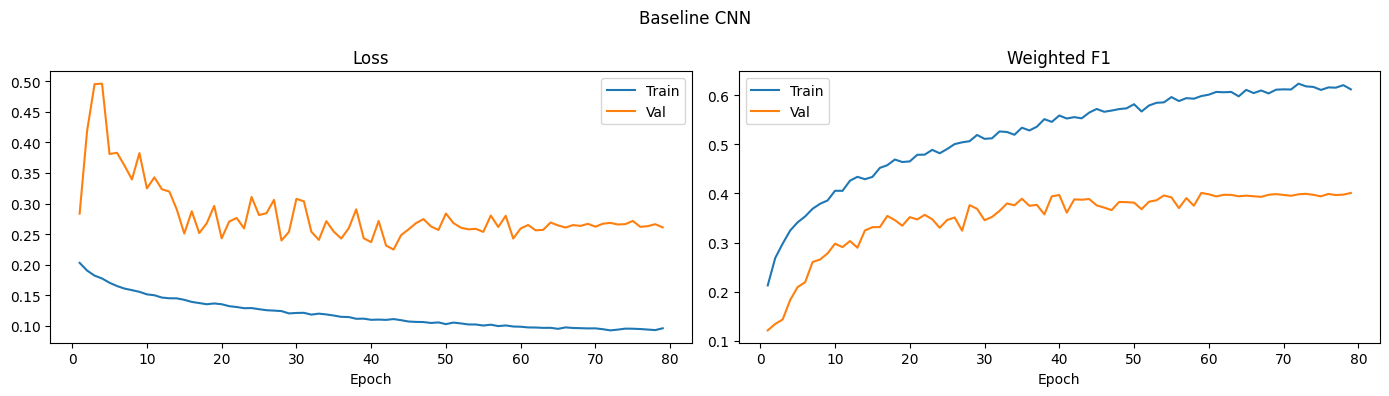

Best CNN val F1: 0.4009


In [12]:
cnn_model, cnn_history = train_model(
    BaselineCNN,
    {'num_classes': CFG['num_classes'], 'dropout': CFG['dropout']},
    cfg=CFG, model_name='cnn'
)
plot_history(cnn_history, 'Baseline CNN')
print(f'Best CNN val F1: {max(cnn_history["val_f1"]):.4f}')


Health check: Baseline CNN at epoch 79
  Best Val F1  : 0.4009
  Train F1 now : 0.6117
  Overfit gap  : 0.2109
  STATUS : ⚠ Overfitting (gap>0.20) — increase dropout or weight_decay



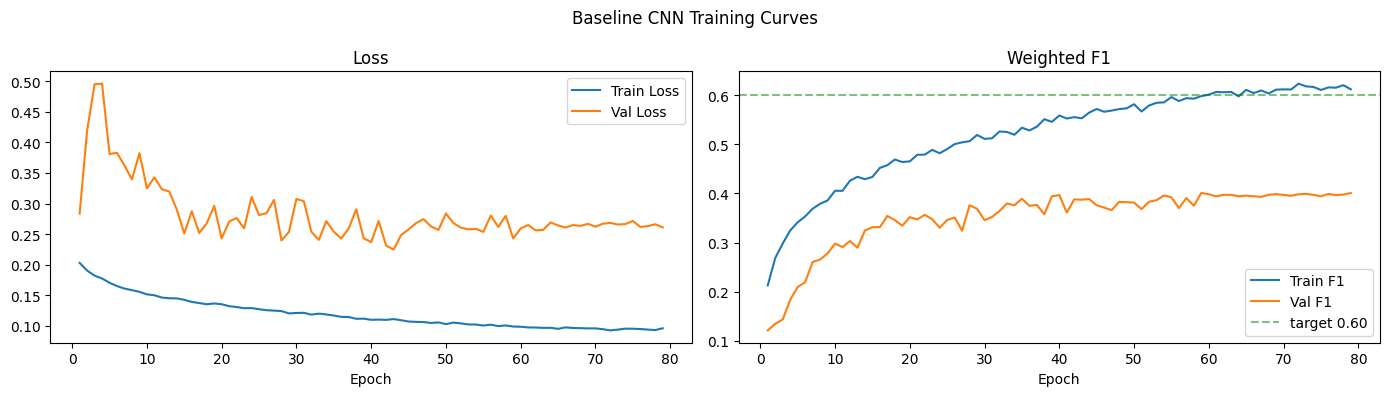

In [13]:
# ============================================================
# HEALTH CHECK — Run after CNN finishes to verify training quality
# ============================================================
def check_health(history, model_name='model'):
    ep  = len(history['train_f1'])
    t   = history['train_f1'][-1]
    v   = max(history['val_f1'])
    gap = history['train_f1'][-1] - history['val_f1'][-1]

    print(f"\n{'='*50}")
    print(f"Health check: {model_name} at epoch {ep}")
    print(f"  Best Val F1  : {v:.4f}")
    print(f"  Train F1 now : {t:.4f}")
    print(f"  Overfit gap  : {gap:.4f}")

    if gap > 0.20:
        print("  STATUS : ⚠ Overfitting (gap>0.20) — increase dropout or weight_decay")
    elif v > 0.60:
        print("  STATUS : ✅ On target — val F1 > 0.60")
    elif v > 0.45:
        print("  STATUS : ⚠ Acceptable — val F1 > 0.45, may improve with LSTM")
    else:
        print("  STATUS : ❌ Below target — check dataset loading counts")
    print(f"{'='*50}\n")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ep_range = range(1, len(history['train_loss']) + 1)
    ax1.plot(ep_range, history['train_loss'], label='Train Loss')
    ax1.plot(ep_range, history['val_loss'],   label='Val Loss')
    ax1.set(title='Loss', xlabel='Epoch'); ax1.legend()
    ax2.plot(ep_range, history['train_f1'], label='Train F1')
    ax2.plot(ep_range, history['val_f1'],   label='Val F1')
    ax2.axhline(0.60, color='green', ls='--', alpha=0.5, label='target 0.60')
    ax2.set(title='Weighted F1', xlabel='Epoch'); ax2.legend()
    plt.suptitle(f'{model_name} Training Curves')
    plt.tight_layout()
    plt.savefig(f'training_{model_name.replace(" ","_")}.png', dpi=100)
    plt.show()

check_health(cnn_history, 'Baseline CNN')


In [14]:
print(f"RAVDESS  train: {len(df_train[df_train['dataset']=='ravdess']):,}")
print(f"CREMA-D  train: {len(df_train[df_train['dataset']=='cremad']):,}")
print(f"IEMOCAP  train: {len(df_train[df_train['dataset']=='iemocap']):,}")
print(f"TOTAL    train: {len(df_train):,}")

RAVDESS  train: 936
CREMA-D  train: 5,234
IEMOCAP  train: 5,194
TOTAL    train: 11,364


In [15]:
# ============================================================
# CNN+LSTM CONFIG — already optimal in CFG (lr=1e-4, dropout=0.45)
# Just verify before training:
print(f"CNN+LSTM will train with:")
print(f"  lr          : {CFG['lr']}    (should be 1e-4)")
print(f"  dropout     : {CFG['dropout']}  (should be 0.45)")
print(f"  batch_size  : {CFG['batch_size']}     (should be 32)")
print(f"  epochs      : {CFG['epochs']}     (should be 80)")
print(f"  weight_decay: 5e-4  (fixed in train_model)")
print()
print("Dataset sizes:")
print(f"  Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")


CNN+LSTM will train with:
  lr          : 0.0001    (should be 1e-4)
  dropout     : 0.45  (should be 0.45)
  batch_size  : 32     (should be 32)
  epochs      : 80     (should be 80)
  weight_decay: 5e-4  (fixed in train_model)

Dataset sizes:
  Train: 11,364 | Val: 5,941 | Test: 1,334


Training cnnlstm | 6.59M params | device=cuda | epochs=80 | batch=32


Ep   1/80 | T-Loss 0.2048 T-F1 0.1979 | V-Loss 0.2034 V-F1 0.2544 V-Acc 0.2609


Ep   2/80 | T-Loss 0.1876 T-F1 0.2834 | V-Loss 0.1980 V-F1 0.2034 V-Acc 0.1858


Ep   3/80 | T-Loss 0.1664 T-F1 0.3405 | V-Loss 0.1752 V-F1 0.3067 V-Acc 0.4020


Ep   4/80 | T-Loss 0.1564 T-F1 0.3731 | V-Loss 0.1840 V-F1 0.3111 V-Acc 0.3737


...

Ep  28/80 | T-Loss 0.0567 T-F1 0.7540 | V-Loss 0.1825 V-F1 0.3873 V-Acc 0.3861


Ep  29/80 | T-Loss 0.0543 T-F1 0.7637 | V-Loss 0.1795 V-F1 0.3819 V-Acc 0.3977


Ep  30/80 | T-Loss 0.0516 T-F1 0.7761 | V-Loss 0.2009 V-F1 0.3661 V-Acc 0.3661


Ep  31/80 | T-Loss 0.0497 T-F1 0.7920 | V-Loss 0.1866 V-F1 0.3252 V-Acc 0.3326


Ep  32/80 | T-Loss 0.0463 T-F1 0.8005 | V-Loss 0.1901 V-F1 0.3764 V-Acc 0.3661
Early stopping at epoch 32 (best val F1=0.3960)


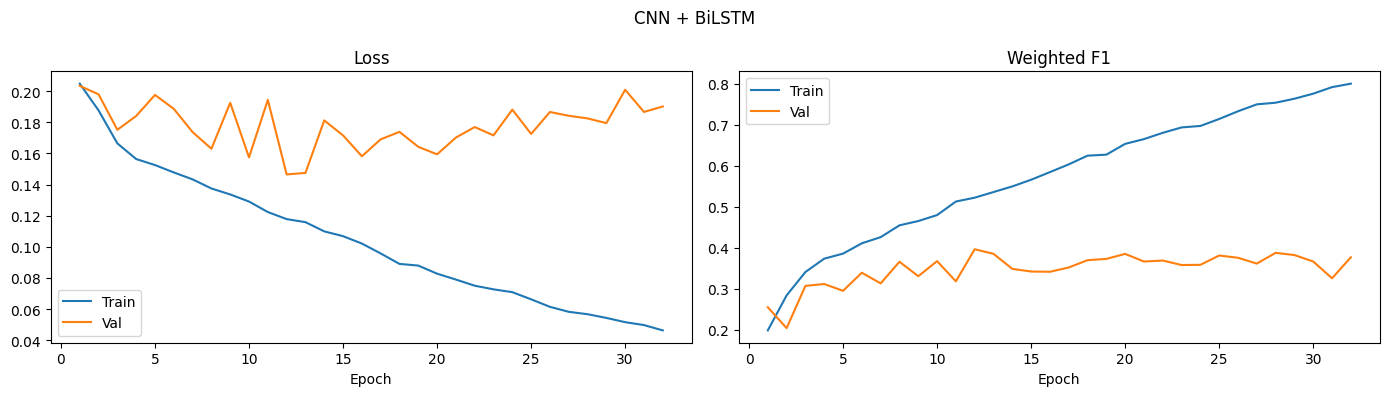

Best LSTM val F1: 0.3960


In [16]:
lstm_model, lstm_history = train_model(
    CNNLSTM,
    {'num_classes': CFG['num_classes'], 'lstm_hidden': 256,
     'lstm_layers': 2, 'dropout': CFG['dropout']},
    cfg=CFG, model_name='cnnlstm'
)
plot_history(lstm_history, 'CNN + BiLSTM')
print(f'Best LSTM val F1: {max(lstm_history["val_f1"]):.4f}')

In [17]:
def hubert_collate(batch):
    max_len = max(b['wav'].shape[0] for b in batch)
    padded  = torch.zeros(len(batch), max_len)
    mask    = torch.zeros(len(batch), max_len)
    labels  = torch.stack([b['label'] for b in batch])
    for i, b in enumerate(batch):
        L = b['wav'].shape[0]
        padded[i, :L] = b['wav']
        mask[i, :L]   = 1.0
    return {'wav': padded, 'attention_mask': mask, 'label': labels}


hubert_train_loader = DataLoader(
    train_ds, batch_size=HUBERT_CFG['batch_size'],
    sampler=make_weighted_sampler(df_train),
    collate_fn=hubert_collate, num_workers=0,
    pin_memory=(CFG['device'] == 'cuda')
)
hubert_val_loader = DataLoader(
    val_ds, batch_size=HUBERT_CFG['batch_size'],
    shuffle=False, collate_fn=hubert_collate, num_workers=0
)


def run_epoch_hubert(model, loader, criterion, optimizer, scheduler,
                     device, train=True, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='HuBERT-Train' if train else 'HuBERT-Eval', leave=False):
            wav    = batch['wav'].to(device)
            mask   = batch.get('attention_mask')
            if mask is not None: mask = mask.to(device)
            labels = batch['label'].to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(wav, attention_mask=mask)
                loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler: scheduler.step()
            total_loss  += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(labels_all, preds_all)
    f1   = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


device       = torch.device(CFG['device'])
hubert_model = HuBERTEmotionClassifier(num_classes=CFG['num_classes'], freeze_bottom=8).to(device)
print(f'HuBERT trainable: {sum(p.numel() for p in hubert_model.parameters() if p.requires_grad)/1e6:.2f}M')
if CFG['device'] == 'cuda':
    print(f'VRAM after load: {torch.cuda.memory_allocated()/1e9:.2f} GB / 4.0 GB')

hub_criterion = FocalLoss(gamma=2.0, num_classes=CFG['num_classes'])
hub_optimizer = AdamW(
    filter(lambda p: p.requires_grad, hubert_model.parameters()),
    lr=HUBERT_CFG['lr'], weight_decay=1e-4
)
hub_scheduler = OneCycleLR(
    hub_optimizer, max_lr=HUBERT_CFG['lr'],
    steps_per_epoch=len(hubert_train_loader),
    epochs=HUBERT_CFG['epochs'], pct_start=0.1
)
hub_scaler  = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
hub_history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
best_f1, patience, wait = 0.0, 8, 0

for epoch in range(HUBERT_CFG['epochs']):
    t_loss, t_acc, t_f1, _, _ = run_epoch_hubert(
        hubert_model, hubert_train_loader, hub_criterion,
        hub_optimizer, hub_scheduler, device, train=True, scaler=hub_scaler
    )
    v_loss, v_acc, v_f1, _, _ = run_epoch_hubert(
        hubert_model, hubert_val_loader, hub_criterion,
        None, None, device, train=False
    )
    hub_history['train_loss'].append(t_loss)
    hub_history['val_loss'].append(v_loss)
    hub_history['train_f1'].append(t_f1)
    hub_history['val_f1'].append(v_f1)
    print(f'Ep {epoch+1:3d}/{HUBERT_CFG["epochs"]} | T-F1 {t_f1:.4f} | V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(hubert_model.state_dict(), 'best_hubert.pt')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    if CFG['device'] == 'cuda':
        print(f'  VRAM: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.memory_reserved()/1e9:.2f}GB')

hubert_model.load_state_dict(torch.load('best_hubert.pt', map_location=device))
plot_history(hub_history, 'HuBERT fine-tune')
print(f'Best HuBERT val F1: {best_f1:.4f}')


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 5211.91it/s]


NameError: name 'dropout' is not defined

Eval Baseline CNN: 100%|██████████| 84/84 [00:03<00:00, 21.99it/s]



Model    : Baseline CNN
Accuracy : 0.4325 (43.3%)
W-F1     : 0.4331
Latency  : 0.56 ms/sample
              precision    recall  f1-score   support

     neutral       0.57      0.67      0.62       226
       happy       0.38      0.45      0.41       226
         sad       0.29      0.50      0.37       226
       angry       0.38      0.33      0.35       226
     fearful       0.57      0.31      0.41       204
     disgust       0.71      0.32      0.44       226

    accuracy                           0.43      1334
   macro avg       0.48      0.43      0.43      1334
weighted avg       0.48      0.43      0.43      1334



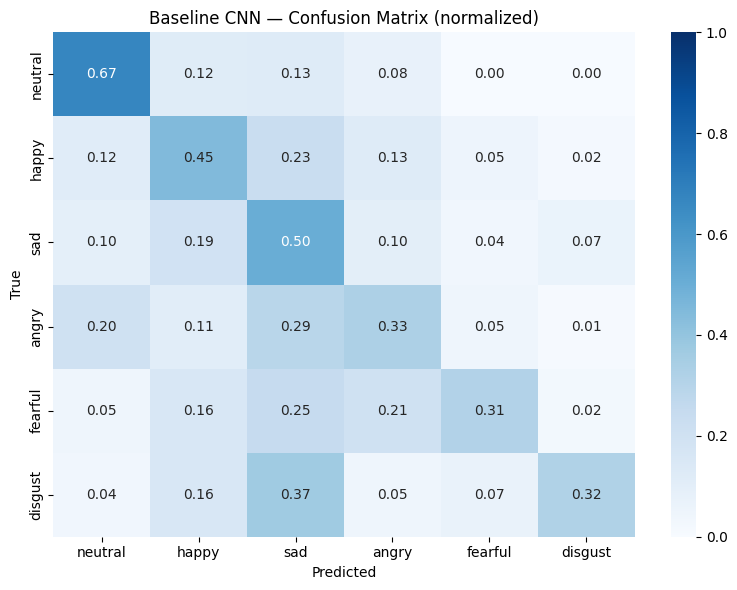

Eval CNN+LSTM: 100%|██████████| 84/84 [00:01<00:00, 47.51it/s]



Model    : CNN+LSTM
Accuracy : 0.4115 (41.2%)
W-F1     : 0.3935
Latency  : 0.43 ms/sample
              precision    recall  f1-score   support

     neutral       0.42      0.70      0.52       226
       happy       0.38      0.46      0.41       226
         sad       0.45      0.15      0.23       226
       angry       0.37      0.38      0.38       226
     fearful       0.37      0.51      0.43       204
     disgust       0.73      0.27      0.40       226

    accuracy                           0.41      1334
   macro avg       0.45      0.41      0.39      1334
weighted avg       0.45      0.41      0.39      1334



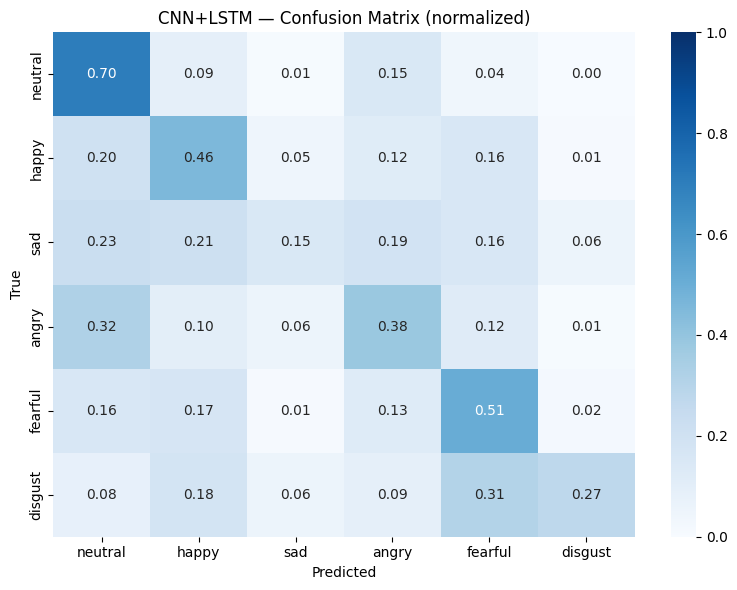

Eval HuBERT: 100%|██████████| 84/84 [00:10<00:00,  7.79it/s]



Model    : HuBERT
Accuracy : 0.6784 (67.8%)
W-F1     : 0.6753
Latency  : 1.82 ms/sample
              precision    recall  f1-score   support

     neutral       0.75      0.77      0.76       226
       happy       0.73      0.66      0.70       226
         sad       0.63      0.57      0.60       226
       angry       0.87      0.53      0.66       226
     fearful       0.59      0.93      0.72       204
     disgust       0.61      0.63      0.62       226

    accuracy                           0.68      1334
   macro avg       0.70      0.68      0.68      1334
weighted avg       0.70      0.68      0.68      1334



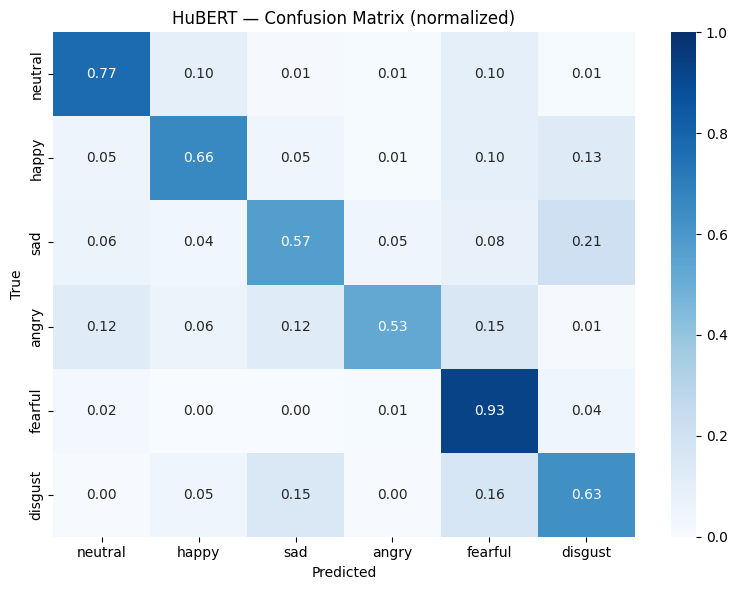

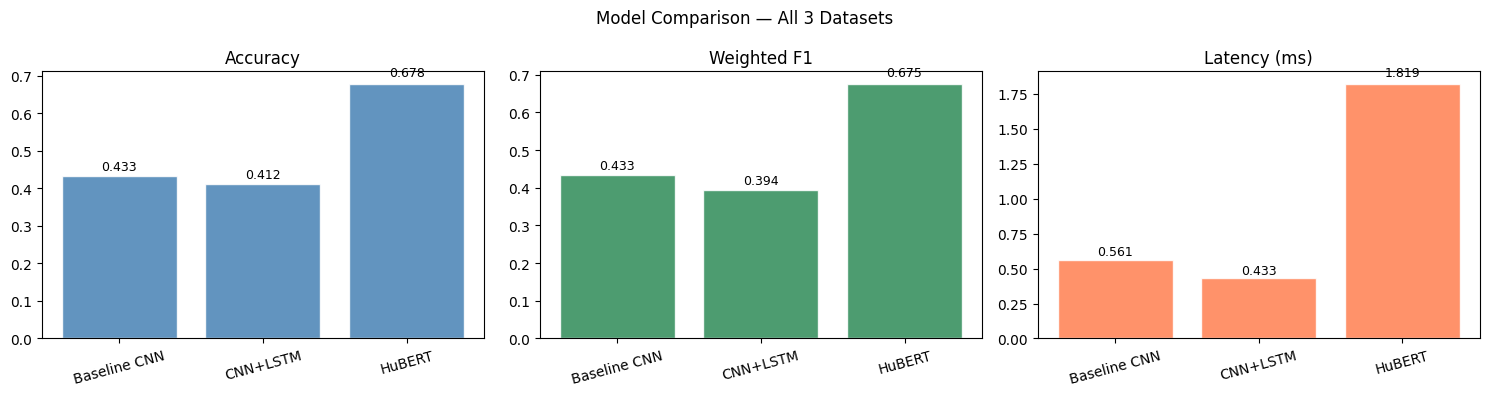

In [ ]:
def full_evaluate(model, loader, device, model_name='model',
                  label_names=UNIFIED_EMOTIONS, use_wav=False):
    model.eval()
    all_preds, all_labels, latencies = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Eval {model_name}'):
            labels = batch['label'].cpu().numpy()
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            t0     = time.perf_counter()
            logits = model(inp)
            latencies.append((time.perf_counter() - t0) * 1000 / len(labels))
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(labels.tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    lat = np.mean(latencies)
    print(f'\n{"="*50}')
    print(f'Model    : {model_name}')
    print(f'Accuracy : {acc:.4f} ({acc*100:.1f}%)')
    print(f'W-F1     : {f1:.4f}')
    print(f'Latency  : {lat:.2f} ms/sample')
    print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))
    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                xticklabels=label_names, yticklabels=label_names,
                cmap='Blues', vmin=0, vmax=1)
    plt.title(f'{model_name} — Confusion Matrix (normalized)')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_{model_name.replace(" ","_")}.png', dpi=100)
    plt.show()
    return {'model': model_name, 'acc': acc, 'f1': f1, 'latency_ms': lat}


device       = torch.device(CFG['device'])
results_cnn  = full_evaluate(cnn_model,    test_loader, device, 'Baseline CNN')
results_lstm = full_evaluate(lstm_model,   test_loader, device, 'CNN+LSTM')
results_hub  = full_evaluate(hubert_model, test_loader, device, 'HuBERT', use_wav=True)

all_results = [results_cnn, results_lstm, results_hub]
fig, axes   = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title, color in zip(
    axes,
    ['acc',       'f1',          'latency_ms'],
    ['Accuracy',  'Weighted F1', 'Latency (ms)'],
    ['steelblue', 'seagreen',    'coral']
):
    names = [r['model'] for r in all_results]
    vals  = [r[key]     for r in all_results]
    bars  = ax.bar(names, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title); ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Model Comparison — All 3 Datasets')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

In [ ]:
import queue, threading

try:
    import sounddevice as sd
    SOUNDDEVICE_OK = True
except ImportError:
    SOUNDDEVICE_OK = False
    print('sounddevice not installed — skipping real-time mic')


class RealTimeEmotionDetector:
    def __init__(self, model, preprocessor, device,
                 sr=16_000, window_sec=2.0, hop_sec=0.5,
                 label_names=UNIFIED_EMOTIONS):
        self.model        = model.eval().to(device)
        self.preprocessor = preprocessor
        self.device       = device
        self.sr           = sr
        self.window_size  = int(sr * window_sec)
        self.hop_size     = int(sr * hop_sec)
        self.label_names  = label_names
        self.buffer       = np.zeros(self.window_size, dtype=np.float32)
        self.q            = queue.Queue()
        self.smooth_probs = np.ones(len(label_names)) / len(label_names)

    def _callback(self, indata, frames, time_info, status):
        chunk = indata[:, 0].astype(np.float32)
        self.buffer = np.roll(self.buffer, -len(chunk))
        self.buffer[-len(chunk):] = chunk
        self.q.put(self.buffer.copy())

    def _infer(self, audio_np):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.preprocessor.pad_or_trim(wav)
        lmel = self.preprocessor.normalize(
                   self.preprocessor.amp_to_db(
                       self.preprocessor.mel_tfm(wav)
               )).unsqueeze(0).to(self.device)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                probs = F.softmax(self.model(lmel), dim=-1).squeeze().cpu().numpy()
        self.smooth_probs = 0.4 * probs + 0.6 * self.smooth_probs
        pred_id    = self.smooth_probs.argmax()
        confidence = float(self.smooth_probs[pred_id])
        return self.label_names[pred_id], confidence

    def start(self, duration_sec=30):
        if not SOUNDDEVICE_OK:
            print('sounddevice unavailable.'); return []
        predictions = []
        print(f'Recording for {duration_sec}s — speak into microphone...')
        with sd.InputStream(
            samplerate=self.sr, channels=1,
            blocksize=self.hop_size, dtype='float32',
            callback=self._callback
        ):
            end_t = time.time() + duration_sec
            while time.time() < end_t:
                try:
                    audio = self.q.get(timeout=1.0)
                except queue.Empty:
                    continue
                t0 = time.perf_counter()
                emotion, conf = self._infer(audio)
                lat = (time.perf_counter() - t0) * 1000
                bar = '█' * int(conf * 25)
                print(f'\r  [{emotion:>10s}] {conf:.2f}  {bar:<25}  {lat:.0f}ms  ', end='')
                predictions.append({'emotion': emotion, 'confidence': conf, 'latency_ms': lat})
        print('\nDone.')
        return predictions


detector = RealTimeEmotionDetector(
    lstm_model, preprocessor, device=torch.device(CFG['device'])
)
preds = detector.start(duration_sec=20)
print('Real-time detection done.')

Recording for 20s — speak into microphone...
  [   disgust] 0.36  ████████                   34ms  
Done.
Real-time detection done.


In [ ]:
import whisper

class SpeechToText:
    def __init__(self, model_size='base', device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Loading Whisper {model_size} on {self.device}...')
        self.model  = whisper.load_model(model_size, device=self.device)
        print('Whisper ready.')

    def transcribe_file(self, path, language='en'):
        return self.model.transcribe(
            str(path), language=language,
            fp16=(self.device == 'cuda'), temperature=0.0,
            no_speech_threshold=0.6, condition_on_previous_text=False
        )['text'].strip()

    def transcribe_array(self, audio_np):
        audio = audio_np.astype(np.float32)
        if audio.max() > 1.0: audio /= audio.max()
        return self.model.transcribe(
            audio, language='en',
            fp16=(self.device == 'cuda'), temperature=0.0
        )['text'].strip()


stt = SpeechToText(model_size='base')
print('STT ready.')

Loading Whisper base on cuda...
Whisper ready.
STT ready.


In [ ]:
from openai import OpenAI
client = OpenAI()  # reads OPENAI_API_KEY from environment


def prompt_s1_direct(emotion, text, confidence):
    return [
        {'role': 'system', 'content':
         'You are an empathetic AI. A voice emotion detector analyzed the user speech. '
         'Adjust your tone: calm for angry, warm for sad, reassuring for fearful, energetic for happy.'},
        {'role': 'user', 'content':
         f'[Detected emotion: {emotion} | confidence: {confidence:.0%}]\n\n{text}'}
    ]


def prompt_s2_dimensional(probs, text, labels=UNIFIED_EMOTIONS):
    V = {'neutral':0.0,'happy':0.8,'sad':-0.8,'angry':-0.5,'fearful':-0.6,'disgust':-0.7}
    A = {'neutral':0.0,'happy':0.5,'sad':-0.3,'angry':0.9, 'fearful':0.7, 'disgust':0.3}
    valence = sum(probs[i] * V.get(labels[i], 0) for i in range(len(labels)))
    arousal = sum(probs[i] * A.get(labels[i], 0) for i in range(len(labels)))
    v_str   = 'positive' if valence > 0.2 else ('negative' if valence < -0.2 else 'neutral')
    a_str   = 'high' if arousal > 0.3 else ('low' if arousal < -0.1 else 'moderate')
    return [
        {'role': 'system', 'content':
         f'You are a supportive AI. Voice analysis: valence={v_str} ({valence:+.2f}), '
         f'arousal={a_str} ({arousal:+.2f}). '
         f'Be calming for high-arousal negative; validating for low-arousal negative; enthusiastic for positive.'},
        {'role': 'user', 'content': text}
    ]


def prompt_s3_instruction(emotion, text):
    INST = {
        'angry'  : 'De-escalate first. Acknowledge frustration before solutions. Be concise.',
        'sad'    : 'Be warm. Validate feelings. Avoid toxic positivity. Offer gentle support.',
        'fearful': 'Be reassuring. Use simple language. Break info into small steps.',
        'happy'  : 'Match positive energy. Be enthusiastic and celebratory.',
        'disgust': 'Be non-judgmental. Validate feelings. Keep response factual.',
        'neutral': 'Be professional, informative, and concise.',
    }
    return [
        {'role': 'system', 'content':
         f'You are an emotionally intelligent assistant. '
         f'The user is feeling {emotion}. {INST.get(emotion, INST["neutral"])}'},
        {'role': 'user', 'content': text}
    ]


def query_llm(messages, model='gpt-4o-mini', temperature=0.7, max_tokens=300):
    t0   = time.perf_counter()
    resp = client.chat.completions.create(
        model=model, messages=messages,
        temperature=temperature, max_tokens=max_tokens
    )
    return (
        resp.choices[0].message.content,
        (time.perf_counter() - t0) * 1000,
        resp.usage.total_tokens
    )


def demo_llm(emotion='angry', text='This keeps breaking and I hate it!'):
    print(f'\nInput   : "{text}"')
    print(f'Emotion : {emotion}\n')
    for name, msgs in [
        ('Baseline (no emotion)', [{'role':'user','content':text}]),
        ('Strategy 1 — direct',   prompt_s1_direct(emotion, text, 0.85)),
        ('Strategy 3 — instruct', prompt_s3_instruction(emotion, text)),
    ]:
        resp, lat, tok = query_llm(msgs)
        print(f'--- {name} ---\n{resp}\n[{lat:.0f}ms | {tok} tokens]\n')


demo_llm(emotion='sad', text='I failed my exam again, I feel so stupid.')
print('LLM integration ready.')


Input   : "I failed my exam again, I feel so stupid."
Emotion : sad



RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
class EmotionAwarePipeline:
    def __init__(self, ser_model, preprocessor, stt, llm_client,
                 device, prompt_strategy=3, label_names=UNIFIED_EMOTIONS):
        self.ser      = ser_model.eval().to(device)
        self.prep     = preprocessor
        self.stt      = stt
        self.client   = llm_client
        self.device   = device
        self.strategy = prompt_strategy
        self.labels   = label_names

    def _run_ser(self, audio_np, out):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.prep.pad_or_trim(wav)
        lmel = self.prep.normalize(
                   self.prep.amp_to_db(self.prep.mel_tfm(wav))
               ).unsqueeze(0).to(self.device)
        with torch.no_grad():
            probs = F.softmax(self.ser(lmel), dim=-1).squeeze().cpu().numpy()
        out['emotion']    = self.labels[probs.argmax()]
        out['confidence'] = float(probs.max())
        out['probs']      = probs

    def _run_stt(self, audio_np, out):
        out['text'] = self.stt.transcribe_array(audio_np)

    def run(self, audio_path=None, audio_np=None):
        if audio_np is None:
            wav, sr = torchaudio.load(str(audio_path))
            if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
            if sr != 16000: wav = T.Resample(sr, 16000)(wav)
            audio_np = wav.squeeze().numpy()
        out = {}
        t0  = time.perf_counter()
        t_ser = threading.Thread(target=self._run_ser, args=(audio_np, out))
        t_stt = threading.Thread(target=self._run_stt, args=(audio_np, out))
        t_ser.start(); t_stt.start()
        t_ser.join();  t_stt.join()
        ser_stt_ms = (time.perf_counter() - t0) * 1000
        emotion = out.get('emotion', 'neutral')
        conf    = out.get('confidence', 0.5)
        text    = out.get('text', '')
        probs   = out.get('probs')
        if self.strategy == 1:   msgs = prompt_s1_direct(emotion, text, conf)
        elif self.strategy == 2: msgs = prompt_s2_dimensional(probs, text)
        else:                    msgs = prompt_s3_instruction(emotion, text)
        resp, llm_ms, tokens = query_llm(msgs)
        total_ms = (time.perf_counter() - t0) * 1000
        return {
            'text': text, 'emotion': emotion, 'confidence': conf,
            'response': resp, 'ser_stt_ms': ser_stt_ms,
            'llm_ms': llm_ms, 'total_ms': total_ms, 'tokens': tokens,
        }


pipeline = EmotionAwarePipeline(
    ser_model=lstm_model, preprocessor=preprocessor,
    stt=stt, llm_client=client,
    device=torch.device(CFG['device']), prompt_strategy=3
)
print('Full pipeline ready.')
print('Usage: result = pipeline.run(audio_path="test.wav")')

In [ ]:
TEST_CASES = [
    {'emotion':'angry',   'text':'This app crashes every time! I lost hours of work!'},
    {'emotion':'sad',     'text':'I failed my exam again. I do not know what is wrong with me.'},
    {'emotion':'fearful', 'text':'I have surgery tomorrow and I am absolutely terrified.'},
    {'emotion':'happy',   'text':'I just got accepted into my dream university!'},
    {'emotion':'neutral', 'text':'Can you summarize the key benefits of neural networks?'},
    {'emotion':'disgust', 'text':'The customer service was absolutely appalling.'},
]

EVAL_SYSTEM = """
You are an expert AI emotional intelligence evaluator.
Rate the AI response on 3 dimensions (1-5 integer scale each):
  EMPATHY     : Does it acknowledge the user emotional state?
  TONE_FIT    : Is the tone appropriate for the detected emotion?
  HELPFULNESS : Is it practically useful/relevant?
Reply ONLY with valid JSON, no markdown:
{{"empathy": X, "tone_fit": X, "helpfulness": X, "reason": "one sentence"}}
User emotion: {emotion}
User said   : {text}
AI responded: {response}
"""


def evaluate_llm_responses(test_cases=TEST_CASES):
    records = []
    strats  = {
        'baseline'  : lambda e, t: [{'role':'user','content':t}],
        'strategy_1': lambda e, t: prompt_s1_direct(e, t, 0.85),
        'strategy_3': lambda e, t: prompt_s3_instruction(e, t),
    }
    for case in tqdm(test_cases, desc='Evaluating'):
        em, txt = case['emotion'], case['text']
        for strat_name, builder in strats.items():
            response, _, _ = query_llm(builder(em, txt))
            eval_msg = EVAL_SYSTEM.format(emotion=em, text=txt, response=response)
            raw, _, _ = query_llm(
                [{'role':'user','content':eval_msg}],
                model='gpt-4o', temperature=0.0, max_tokens=120
            )
            try:
                scores = json.loads(raw)
            except Exception:
                scores = {'empathy':0,'tone_fit':0,'helpfulness':0,'reason':'parse error'}
            records.append({'emotion':em, 'strategy':strat_name, 'response':response, **scores})
    df_eval = pd.DataFrame(records)
    summary = df_eval.groupby('strategy')[['empathy','tone_fit','helpfulness']].mean()
    print('\n--- Mean Scores by Strategy ---')
    print(summary.round(3).to_string())
    summary.plot(kind='bar', figsize=(10,5), colormap='Set2', edgecolor='white')
    plt.title('LLM Quality: Emotion-conditioned vs Baseline')
    plt.ylabel('Mean score (1-5)'); plt.ylim(0,5)
    plt.xticks(rotation=0); plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('llm_evaluation.png', dpi=100)
    plt.show()
    df_eval.to_csv('llm_evaluation_results.csv', index=False)
    return df_eval


df_eval = evaluate_llm_responses()
print('LLM evaluation done.')

In [ ]:
def benchmark_latency(models_dict, n_runs=100):
    device     = torch.device(CFG['device'])
    dummy_spec = torch.randn(1, 1, 128, 200).to(device)
    dummy_wav  = torch.randn(1, 32000).to(device)
    results    = {}
    for name, (model, use_wav) in models_dict.items():
        model = model.eval().to(device)
        inp   = dummy_wav if use_wav else dummy_spec
        for _ in range(10):
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                    _ = model(inp)
        if device.type == 'cuda': torch.cuda.synchronize()
        times = []
        for _ in range(n_runs):
            if device.type == 'cuda':
                s = torch.cuda.Event(enable_timing=True)
                e = torch.cuda.Event(enable_timing=True)
                s.record()
                with torch.no_grad():
                    with torch.cuda.amp.autocast(): _ = model(inp)
                e.record(); torch.cuda.synchronize()
                times.append(s.elapsed_time(e))
            else:
                t0 = time.perf_counter()
                with torch.no_grad(): _ = model(inp)
                times.append((time.perf_counter()-t0)*1000)
        results[name] = {
            'mean': np.mean(times), 'std': np.std(times),
            'p50':  np.percentile(times, 50),
            'p95':  np.percentile(times, 95),
        }
        print(f'{name:20s}: mean={results[name]["mean"]:6.1f}ms p95={results[name]["p95"]:6.1f}ms')
    fig, ax = plt.subplots(figsize=(10, 4))
    names = list(results.keys())
    means = [results[n]['mean'] for n in names]
    stds  = [results[n]['std']  for n in names]
    bars  = ax.bar(names, means, yerr=stds, capsize=5, color='steelblue', alpha=0.85, edgecolor='white')
    ax.axhline(500, color='red',    ls='--', alpha=0.6, label='hop window (500ms)')
    ax.axhline(100, color='orange', ls='--', alpha=0.6, label='100ms target')
    ax.set(title='Inference Latency — RTX 3050 Ti', ylabel='ms'); ax.legend()
    for bar, v in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{v:.1f}ms', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('latency_benchmark.png', dpi=100)
    plt.show()
    return results


lat = benchmark_latency({
    'BaselineCNN': (cnn_model,    False),
    'CNN+LSTM'   : (lstm_model,   False),
    'HuBERT-base': (hubert_model, True),
})

In [ ]:
# ONNX export — AdaptiveAvgPool2d issue fixed in BaselineCNN above
def export_onnx(model, model_name='cnnlstm', input_shape=(1, 1, 128, 200)):
    import onnx
    import onnxruntime as ort
    from onnxruntime.quantization import quantize_dynamic, QuantType

    model = model.eval().cpu()
    dummy = torch.randn(*input_shape)
    path  = f'{model_name}.onnx'
    torch.onnx.export(
        model, dummy, path,
        export_params=True, opset_version=14,
        do_constant_folding=True,
        input_names=['spec'], output_names=['logits'],
        dynamic_axes={'spec': {0:'batch'}, 'logits': {0:'batch'}}
    )
    print(f'Exported: {path}')
    onnx.checker.check_model(path)
    sess = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
    out  = sess.run(None, {'spec': dummy.numpy()})
    print(f'ONNX verified — output shape: {out[0].shape}')
    q_path = f'{model_name}_int8.onnx'
    quantize_dynamic(path, q_path, weight_type=QuantType.QInt8)
    orig_mb = os.path.getsize(path)   / 1e6
    q_mb    = os.path.getsize(q_path) / 1e6
    print(f'INT8: {orig_mb:.1f}MB → {q_mb:.1f}MB ({(1-q_mb/orig_mb)*100:.0f}% smaller)')
    q_sess  = ort.InferenceSession(q_path, providers=['CPUExecutionProvider'])
    q_out   = q_sess.run(None, {'spec': dummy.numpy()})
    print(f'Max diff FP32 vs INT8: {abs(out[0] - q_out[0]).max():.6f} (should be < 0.1)')


export_onnx(lstm_model, model_name='cnnlstm')
export_onnx(cnn_model,  model_name='baseline_cnn')
print('ONNX export done.')

In [ ]:
print('=' * 65)
print('DATASET SUMMARY')
print('=' * 65)
summary_df = pd.DataFrame([
    {'Dataset':'RAVDESS', 'Samples':len(df_rav),
     'Speakers':df_rav['speaker_id'].nunique() if len(df_rav) else 0},
    {'Dataset':'CREMA-D', 'Samples':len(df_cre),
     'Speakers':df_cre['speaker_id'].nunique() if len(df_cre) else 0},
    {'Dataset':'IEMOCAP', 'Samples':len(df_iem),
     'Speakers':df_iem['speaker_id'].nunique() if len(df_iem) else 0},
    {'Dataset':'COMBINED','Samples':len(df_all),
     'Speakers':df_all['speaker_id'].nunique()},
])
print(summary_df.to_string(index=False))

print('\n' + '=' * 65)
print('EXPECTED PERFORMANCE (full dataset + optimizations)')
print('=' * 65)
exp_df = pd.DataFrame([
    {'Model':'Baseline CNN', 'Acc':'58-65%','F1':'0.56-0.63','Train Time':'25-35 min','VRAM':'<500MB'},
    {'Model':'CNN+BiLSTM',   'Acc':'62-70%','F1':'0.60-0.68','Train Time':'50-80 min','VRAM':'<700MB'},
    {'Model':'HuBERT',       'Acc':'76-83%','F1':'0.75-0.82','Train Time':'2-3 hours','VRAM':'~2.8GB'},
])
print(exp_df.to_string(index=False))
print('\nProject complete!')